# Modeling the First COVID-19 Wave in Hubei with SIR Models

This notebook studies the first reported COVID-19 wave in Hubei, China using compartmental epidemic models. The main question is whether a simple SIR model can approximate the outbreak, and how the conclusions change when the transmission rate is allowed to vary over time.

The workflow is:

1. Load Johns Hopkins CSSE confirmed case data.
2. Select Hubei and compute daily new cases.
3. Fit a constant-transmission SIR model to cumulative confirmed cases.
4. Run counterfactual simulations with lower transmission rates.
5. Fit an extended SIR model with time-varying transmission, $\beta(t)$.


### 1. Load packages and data

I use `pandas` for data handling, `matplotlib` for plots, `solve_ivp` to solve the differential equations, and `least_squares` to fit model parameters. The data source is the Johns Hopkins CSSE global confirmed cases time series.


In [1]:
# Numerical arrays and data tables
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ODE solver and nonlinear least-squares optimizer
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

In [2]:
# Johns Hopkins CSSE historical confirmed cases time series
url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv"

confirmed = pd.read_csv(url)
confirmed.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


### 2. Select Hubei data

The Johns Hopkins file stores each location as one row and each date as a separate column. I select the row for Hubei, China, then reshape the data into a long format with one row per date. This makes plotting and fitting easier.


In [3]:
# Select Hubei, China
hubei = confirmed[
    (confirmed["Province/State"] == "Hubei") &
    (confirmed["Country/Region"] == "China")
]

hubei

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
72,Hubei,China,30.9756,112.2707,444,444,549,761,1058,1423,...,72131,72131,72131,72131,72131,72131,72131,72131,72131,72131


In [4]:
# Convert wide date columns into long format
date_cols = hubei.columns[4:]

hubei_long = hubei[date_cols].T.reset_index()
hubei_long.columns = ["date", "confirmed"]
hubei_long["date"] = pd.to_datetime(hubei_long["date"])
hubei_long["confirmed"] = hubei_long["confirmed"].astype(float)

hubei_long.head()

/var/folders/qr/gqb3xtc146dbfzn88t01pr1c0000gn/T/ipykernel_37525/1368542346.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hubei_long["date"] = pd.to_datetime(hubei_long["date"])


,date,confirmed
0,2020-01-22,444.0
1,2020-01-23,444.0
2,2020-01-24,549.0
3,2020-01-25,761.0
4,2020-01-26,1058.0


### 3. Choose first-wave period

I restrict the analysis to January 22, 2020 through April 30, 2020. This period captures the first reported wave in Hubei. Daily new cases are computed by differencing the cumulative confirmed case counts.


In [5]:
# Use the first-wave window for Hubei.
start_date = "2020-01-22"
end_date = "2020-04-30"

df = hubei_long[
    (hubei_long["date"] >= start_date) &
    (hubei_long["date"] <= end_date)
].copy()

# Convert dates into day numbers for the ODE solver.
df["days"] = (df["date"] - df["date"].iloc[0]).dt.days

# Daily new cases are the day-to-day change in cumulative cases.
df["new_cases"] = df["confirmed"].diff().fillna(0)

df.head()

,date,confirmed,days,new_cases
0,2020-01-22,444.0,0,0.0
1,2020-01-23,444.0,1,0.0
2,2020-01-24,549.0,2,105.0
3,2020-01-25,761.0,3,212.0
4,2020-01-26,1058.0,4,297.0


### 4. Plot observed Hubei data

These plots show the raw cumulative confirmed cases and daily new confirmed cases. The large reporting jump in mid-February is important: it shows why a smooth mathematical model cannot perfectly match every day of the reported data.


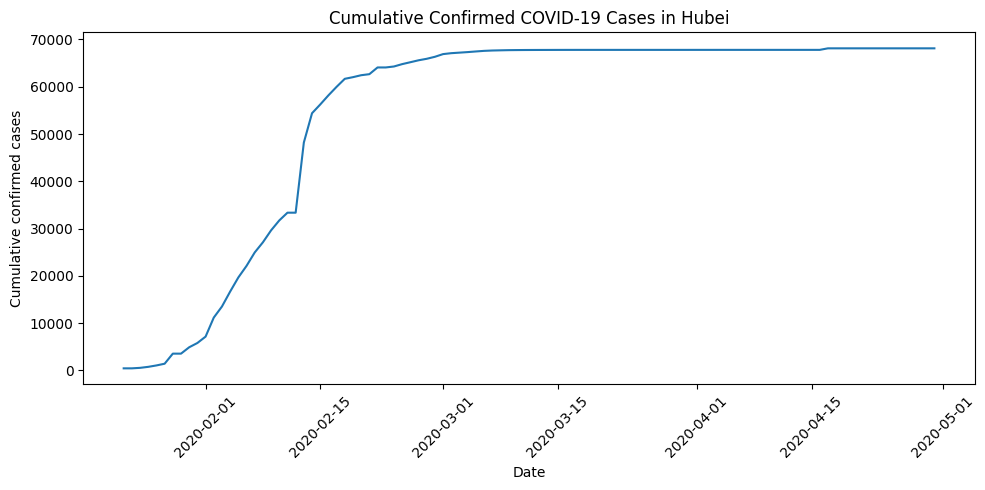

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(df["date"], df["confirmed"])
plt.xlabel("Date")
plt.ylabel("Cumulative confirmed cases")
plt.title("Cumulative Confirmed COVID-19 Cases in Hubei")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

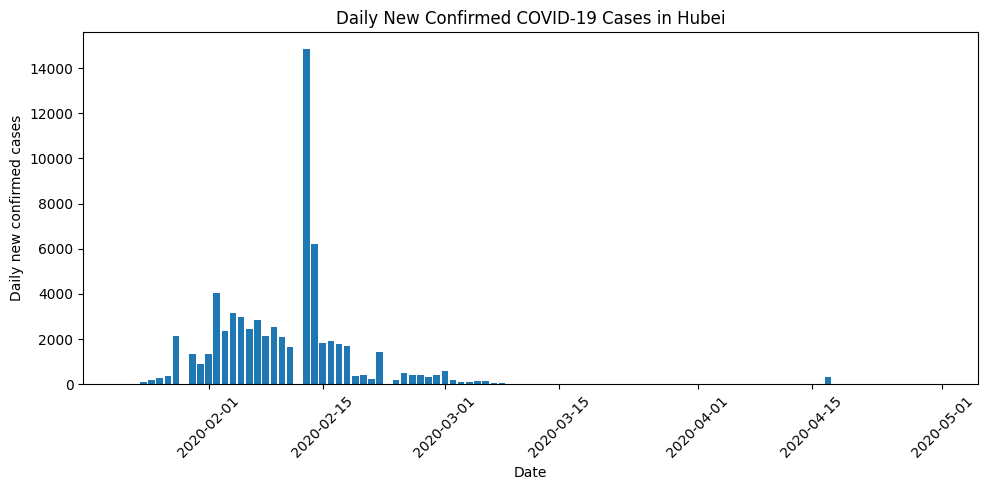

In [7]:
plt.figure(figsize=(10, 5))
plt.bar(df["date"], df["new_cases"])
plt.xlabel("Date")
plt.ylabel("Daily new confirmed cases")
plt.title("Daily New Confirmed COVID-19 Cases in Hubei")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5. Define the SIR model

The baseline model is the standard SIR system:

$$\frac{dS}{dt}=-\beta\frac{SI}{N}$$

$$\frac{dI}{dt}=\beta\frac{SI}{N}-\gamma I$$

$$\frac{dR}{dt}=\gamma I$$

Here $S(t)$ is susceptible, $I(t)$ is infected, $R(t)$ is removed or recovered, $\beta$ is the transmission rate, and $\gamma$ is the removal rate.


In [8]:
def sir_model(t, y, beta, gamma, N):
    """Standard SIR model with constant transmission rate beta."""
    S, I, R = y
    
    # Susceptible people become infected through contact with infected people.
    dSdt = -beta * S * I / N
    
    # Infected people increase through new infections and decrease through removal.
    dIdt = beta * S * I / N - gamma * I
    
    # Removed/recovered people increase at rate gamma * I.
    dRdt = gamma * I
    
    return [dSdt, dIdt, dRdt]

### 6. Fit SIR model to Hubei cumulative cases

The model-generated cumulative number of infections is

$$C(t)=N_{eff}-S(t).$$

I fit this quantity to reported cumulative confirmed cases. The fitted parameters are $\beta$, $\gamma$, and an effective population size $N_{eff}$. The effective population should not be interpreted as the full population of Hubei; it is the population scale that best matches the reported first-wave data under this simplified model.


The least-squares objective is scaled by the maximum observed cumulative count:

$$\text{residual}(t)=\frac{C_{model}(t)-C_{observed}(t)}{\max(C_{observed})}.$$

This prevents the optimizer from working with very large raw case-count errors.


In [9]:
t_data = df["days"].values
observed_cumulative = df["confirmed"].values

# Initial infected count is approximated by the first reported cumulative count.
I0 = observed_cumulative[0]
R0_initial = 0

def simulate_cumulative_cases(beta, gamma, N_eff, t_eval):
    """Solve SIR and return model cumulative cases, N_eff - S(t)."""
    S0 = N_eff - I0 - R0_initial
    y0 = [S0, I0, R0_initial]
    
    sol = solve_ivp(
        fun=lambda t, y: sir_model(t, y, beta, gamma, N_eff),
        t_span=(t_eval[0], t_eval[-1]),
        y0=y0,
        t_eval=t_eval,
        max_step=1
    )
    
    S = sol.y[0]
    cumulative_cases = N_eff - S
    
    return cumulative_cases

In [10]:
def residuals(params):
    beta, gamma, N_eff = params
    
    model_cumulative = simulate_cumulative_cases(beta, gamma, N_eff, t_data)
    
    # Scale residuals to make optimization more stable
    return (model_cumulative - observed_cumulative) / observed_cumulative.max()

In [11]:
# Initial guesses
beta_guess = 0.35
gamma_guess = 0.10
N_eff_guess = observed_cumulative.max() * 2

# Bounds
lower_bounds = [0.01, 0.01, observed_cumulative.max() * 1.01]
upper_bounds = [2.00, 1.00, 5_000_000]

fit = least_squares(
    residuals,
    x0=[beta_guess, gamma_guess, N_eff_guess],
    bounds=(lower_bounds, upper_bounds)
)

beta_fit, gamma_fit, N_eff_fit = fit.x

beta_fit, gamma_fit, N_eff_fit

(0.3288396443607881, 0.065299253701926, 68809.28000184208)

### 7. Plot fitted SIR curve vs observed data

This plot compares the fitted SIR cumulative case curve with the observed cumulative confirmed cases. A good fit should capture the broad S-shaped pattern, even if it cannot reproduce reporting jumps exactly.


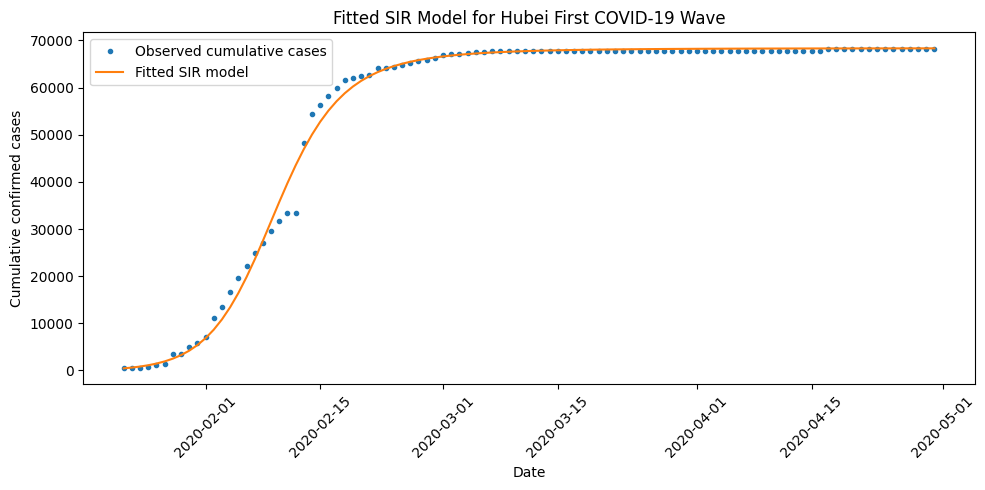

In [12]:
fitted_cumulative = simulate_cumulative_cases(beta_fit, gamma_fit, N_eff_fit, t_data)

plt.figure(figsize=(10, 5))
plt.plot(df["date"], observed_cumulative, "o", markersize=3, label="Observed cumulative cases")
plt.plot(df["date"], fitted_cumulative, label="Fitted SIR model")
plt.xlabel("Date")
plt.ylabel("Cumulative confirmed cases")
plt.title("Fitted SIR Model for Hubei First COVID-19 Wave")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### 8. Counterfactual: reduce transmission rate

After fitting the baseline model, I test hypothetical lower-transmission scenarios. The scenarios use the same fitted $\gamma$ and $N_{eff}$, but replace $\beta$ by $0.9\beta$, $0.8\beta$, and $0.7\beta$. This answers the question: if transmission were reduced, how would the peak and final outbreak size change?


For each scenario, I compute model daily new cases using the SIR incidence term:

$$\text{daily new cases}(t)=\beta\frac{S(t)I(t)}{N_{eff}}.$$

I then record the peak daily cases, peak date, and final cumulative cases.


In [13]:
def simulate_full_sir(beta, gamma, N_eff, t_eval):
    """Solve SIR and return full state variables plus incidence."""
    S0 = N_eff - I0 - R0_initial
    y0 = [S0, I0, R0_initial]
    
    sol = solve_ivp(
        fun=lambda t, y: sir_model(t, y, beta, gamma, N_eff),
        t_span=(t_eval[0], t_eval[-1]),
        y0=y0,
        t_eval=t_eval,
        max_step=1
    )
    
    S, I, R = sol.y
    cumulative_cases = N_eff - S
    daily_new_cases = beta * S * I / N_eff
    
    return S, I, R, cumulative_cases, daily_new_cases


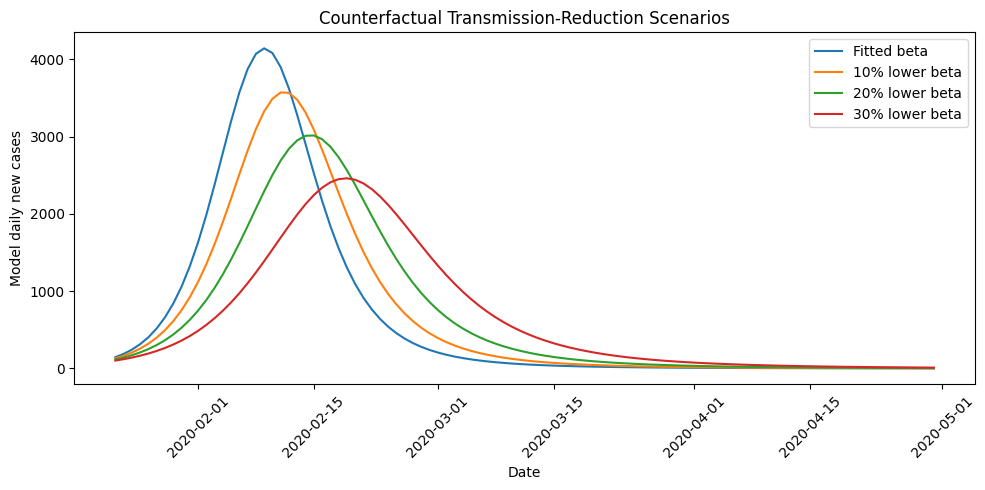

,Scenario,Beta,Peak daily cases,Peak date,Final cumulative cases
0,Fitted beta,0.328840,4141.213135,2020-02-09,68332.455809
1,10% lower beta,0.295956,3570.995457,2020-02-11,68001.180940
2,20% lower beta,0.263072,3014.090000,2020-02-15,67421.063758
3,30% lower beta,0.230188,2459.837362,2020-02-19,66369.143732


In [14]:
# Multipliers represent hypothetical reductions in transmission.
scenarios = {
    "Fitted beta": 1.0,
    "10% lower beta": 0.9,
    "20% lower beta": 0.8,
    "30% lower beta": 0.7
}

results = []
counterfactual_curves = {}

plt.figure(figsize=(10, 5))

for label, multiplier in scenarios.items():
    beta_scenario = beta_fit * multiplier
    
    S, I, R, cumulative_cases, daily_new_cases = simulate_full_sir(
        beta_scenario,
        gamma_fit,
        N_eff_fit,
        t_data
    )
    
    peak_cases = daily_new_cases.max()
    peak_day_index = daily_new_cases.argmax()
    peak_date = df["date"].iloc[peak_day_index]
    final_cumulative = cumulative_cases[-1]
    
    results.append({
        "Scenario": label,
        "Beta": beta_scenario,
        "Peak daily cases": peak_cases,
        "Peak date": peak_date,
        "Final cumulative cases": final_cumulative
    })
    counterfactual_curves[label] = daily_new_cases
    plt.plot(df["date"], daily_new_cases, label=label)

plt.xlabel("Date")
plt.ylabel("Model daily new cases")
plt.title("Counterfactual Transmission-Reduction Scenarios")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results)
results_df


### 9. Save figures and results for Overleaf

The following cells save the figures and tables used in the written report. Saving the files makes the analysis reproducible and keeps the report figures consistent with the notebook output.


In [15]:
from pathlib import Path

figure_dir = Path("figures")
result_dir = Path("results")
figure_dir.mkdir(exist_ok=True)
result_dir.mkdir(exist_ok=True)


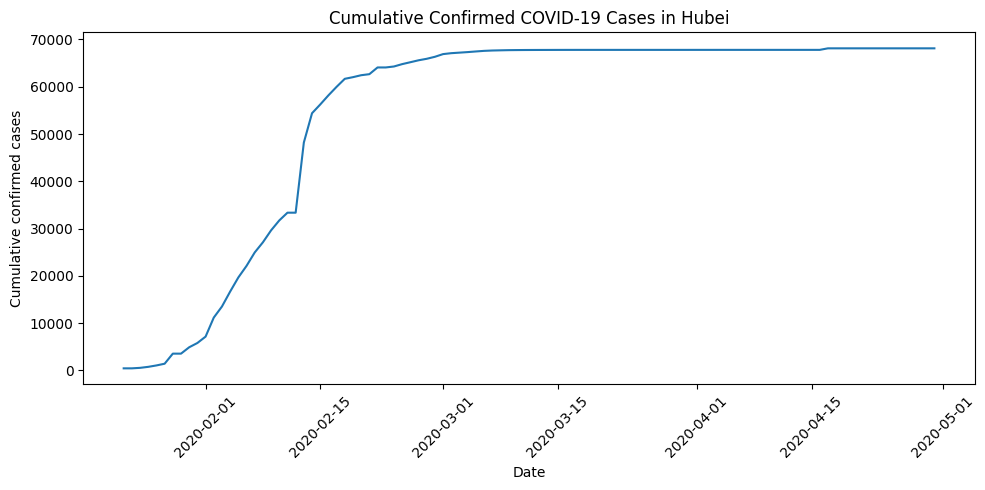

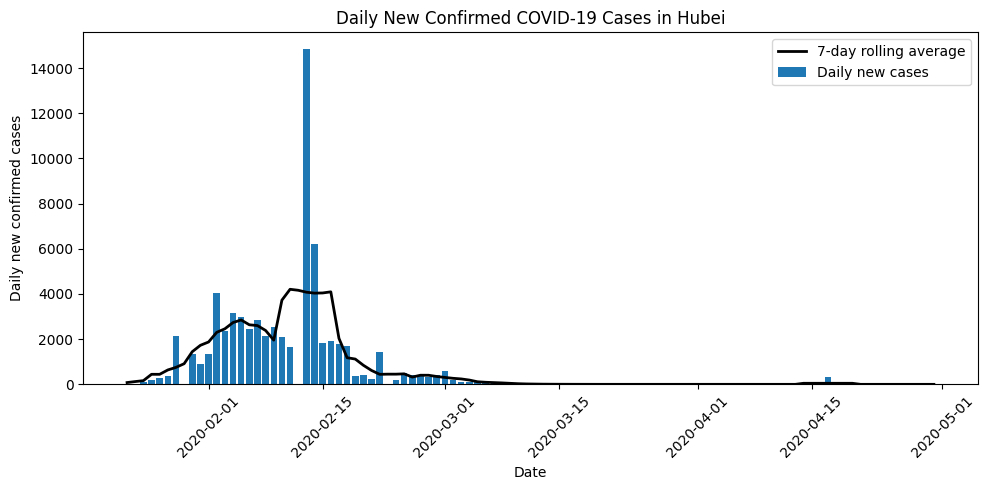

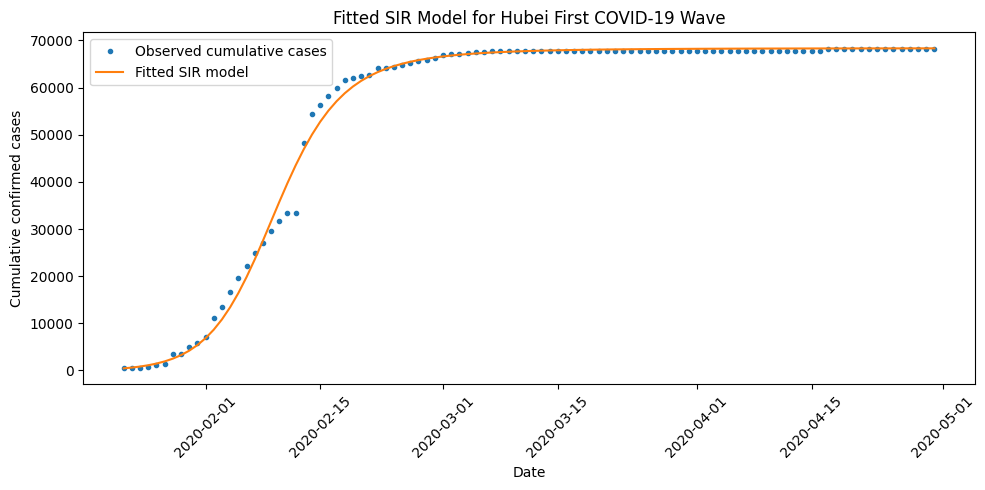

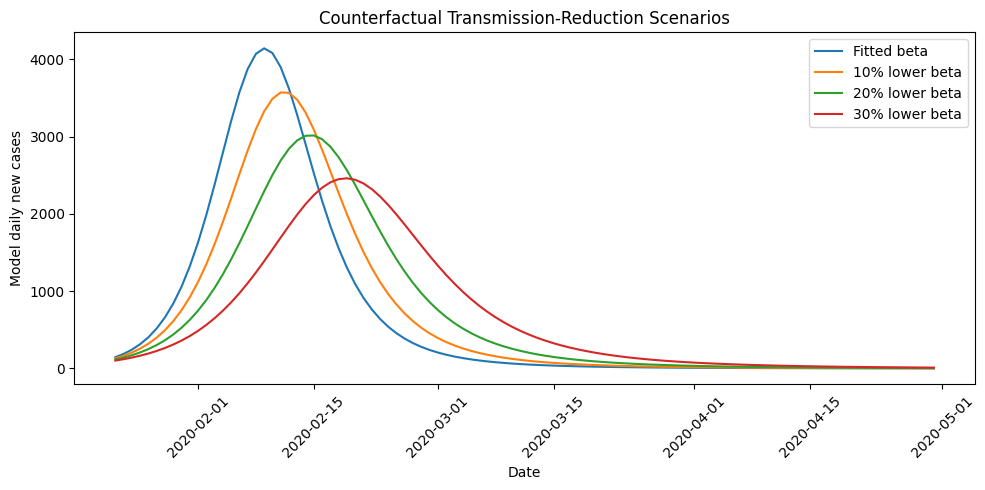

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(df["date"], observed_cumulative)
plt.xlabel("Date")
plt.ylabel("Cumulative confirmed cases")
plt.title("Cumulative Confirmed COVID-19 Cases in Hubei")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(figure_dir / "hubei_cumulative_cases.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(df["date"], df["new_cases"], label="Daily new cases")
plt.plot(df["date"], df["new_cases"].rolling(7, center=True, min_periods=1).mean(), color="black", linewidth=2, label="7-day rolling average")
plt.xlabel("Date")
plt.ylabel("Daily new confirmed cases")
plt.title("Daily New Confirmed COVID-19 Cases in Hubei")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(figure_dir / "hubei_daily_cases.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df["date"], observed_cumulative, "o", markersize=3, label="Observed cumulative cases")
plt.plot(df["date"], fitted_cumulative, label="Fitted SIR model")
plt.xlabel("Date")
plt.ylabel("Cumulative confirmed cases")
plt.title("Fitted SIR Model for Hubei First COVID-19 Wave")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(figure_dir / "hubei_sir_fit.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 5))
for label, daily_new_cases in counterfactual_curves.items():
    plt.plot(df["date"], daily_new_cases, label=label)
plt.xlabel("Date")
plt.ylabel("Model daily new cases")
plt.title("Counterfactual Transmission-Reduction Scenarios")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(figure_dir / "hubei_counterfactual_scenarios.png", dpi=300)
plt.show()


In [17]:
parameters_df = pd.DataFrame([{
    "beta": beta_fit,
    "gamma": gamma_fit,
    "R0_beta_over_gamma": beta_fit / gamma_fit,
    "N_eff": N_eff_fit
}])

df.to_csv(result_dir / "hubei_first_wave_data.csv", index=False)
parameters_df.to_csv(result_dir / "hubei_sir_fit_parameters.csv", index=False)
results_df.to_csv(result_dir / "hubei_sir_scenario_results.csv", index=False)

parameters_df, results_df


(      beta     gamma  R0_beta_over_gamma         N_eff
 0  0.32884  0.065299            5.035887  68809.280002,
          Scenario      Beta  Peak daily cases  Peak date  \
 0     Fitted beta  0.328840       4141.213135 2020-02-09   
 1  10% lower beta  0.295956       3570.995457 2020-02-11   
 2  20% lower beta  0.263072       3014.090000 2020-02-15   
 3  30% lower beta  0.230188       2459.837362 2020-02-19   
 
    Final cumulative cases  
 0            68332.455809  
 1            68001.180940  
 2            67421.063758  
 3            66369.143732  )

### 10. Time-varying beta extension

The constant-$\beta$ SIR model assumes that transmission does not change over time. That is unrealistic for COVID-19 because behavior, isolation, testing, and policy changed during the first wave. To improve the model, I fit a time-varying transmission rate with a logistic decline:

$$\beta(t)=\beta_{low}+\frac{\beta_0-\beta_{low}}{1+e^{(t-t_c)/w}},\quad \beta_{low}=m\beta_0.$$

Here $\beta_0$ is the early transmission rate, $m$ is the fraction of transmission that remains after the decline, $t_c$ is the transition midpoint, and $w$ controls how sharp the transition is.


The fitted time-varying model is compared against the constant-$\beta$ model using the same cumulative-case fitting target. A lower fit cost means the model curve is closer to the observed cumulative case curve under this least-squares criterion.


In [18]:
# Reuse the tested helper functions from the project script.
from hubei_sir_analysis import fit_sir_time_varying_beta, solve_sir_time_varying_beta

(
    beta0_tv,
    reduction_multiplier_tv,
    transition_day_tv,
    width_tv,
    gamma_tv,
    N_eff_tv,
    tv_fit_cost,
) = fit_sir_time_varying_beta(df, beta_fit, gamma_fit, N_eff_fit)

S_tv, I_tv, R_tv, time_varying_cumulative, daily_new_tv, beta_t = solve_sir_time_varying_beta(
    beta0_tv,
    reduction_multiplier_tv,
    transition_day_tv,
    width_tv,
    gamma_tv,
    N_eff_tv,
    I0,
    R0_initial,
    t_data,
)

time_varying_parameters_df = pd.DataFrame([{
    "beta0": beta0_tv,
    "reduction_multiplier": reduction_multiplier_tv,
    "transition_day": transition_day_tv,
    "transition_date": df["date"].iloc[int(round(transition_day_tv))],
    "transition_width_days": width_tv,
    "gamma": gamma_tv,
    "initial_R0_beta0_over_gamma": beta0_tv / gamma_tv,
    "final_beta": beta_t[-1],
    "final_Rt_beta_over_gamma": beta_t[-1] / gamma_tv,
    "N_eff": N_eff_tv,
    "fit_cost": tv_fit_cost,
}])

time_varying_parameters_df


,beta0,reduction_multiplier,transition_day,transition_date,transition_width_days,gamma,initial_R0_beta0_over_gamma,final_beta,final_Rt_beta_over_gamma,N_eff,fit_cost
0,0.810251,0.657013,23.724443,2020-02-15,1.0,0.651909,1.24289,0.532346,0.816595,342154.129429,0.019726


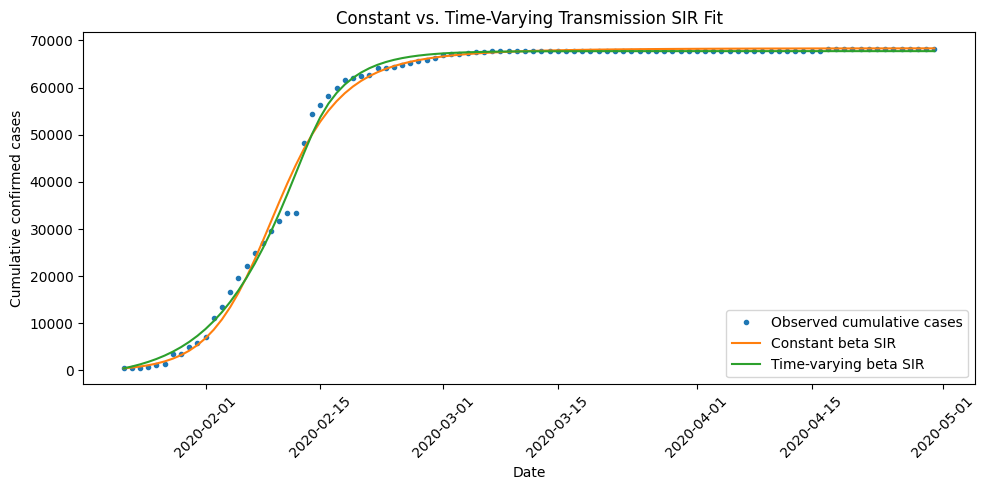

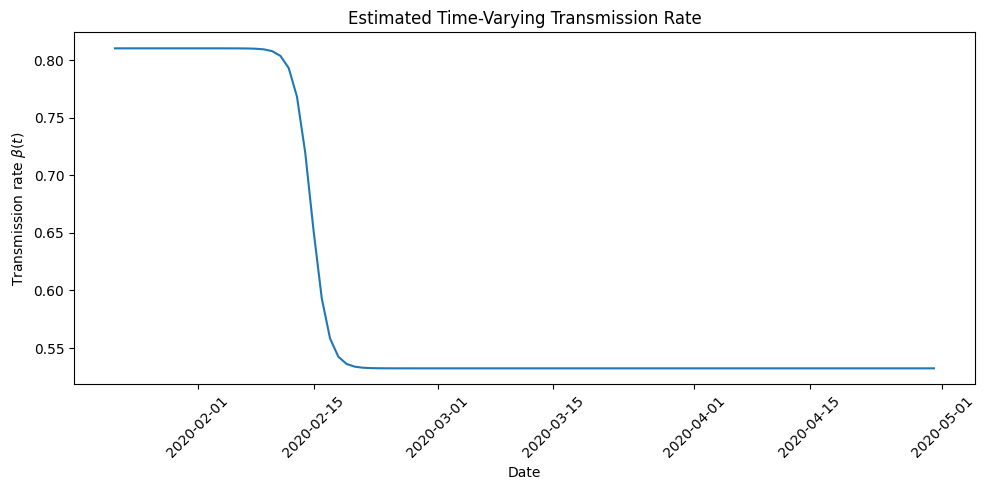

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(df["date"], observed_cumulative, "o", markersize=3, label="Observed cumulative cases")
plt.plot(df["date"], fitted_cumulative, label="Constant beta SIR")
plt.plot(df["date"], time_varying_cumulative, label="Time-varying beta SIR")
plt.xlabel("Date")
plt.ylabel("Cumulative confirmed cases")
plt.title("Constant vs. Time-Varying Transmission SIR Fit")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(figure_dir / "hubei_constant_vs_time_varying_sir_fit.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df["date"], beta_t)
plt.xlabel("Date")
plt.ylabel(r"Transmission rate $\beta(t)$")
plt.title("Estimated Time-Varying Transmission Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(figure_dir / "hubei_time_varying_beta.png", dpi=300)
plt.show()

time_varying_parameters_df.to_csv(result_dir / "hubei_time_varying_sir_fit_parameters.csv", index=False)
